# Meaningful Variations

In [9]:
import os
from math import factorial
import matplotlib.pyplot as plt
import numpy as np

def count_permutations_for_distribution(distribution, n):
    """Calculate number of permutations for a given distribution using multinomial coefficient"""
    numerator = factorial(n)
    denominator = 1
    for count in distribution:
        denominator *= factorial(count)
    return numerator // denominator

def find_all_possible_averages(n_respondents, scores=[1,2,3,4,5]):
    """Find all possible averages for a given number of respondents"""
    min_sum = n_respondents * min(scores)
    max_sum = n_respondents * max(scores)
    
    possible_sums = set()
    
    # Generate all possible sums by checking all distributions
    for n1 in range(n_respondents + 1):
        for n2 in range(n_respondents - n1 + 1):
            for n3 in range(n_respondents - n1 - n2 + 1):
                for n4 in range(n_respondents - n1 - n2 - n3 + 1):
                    n5 = n_respondents - n1 - n2 - n3 - n4
                    total_sum = n1*1 + n2*2 + n3*3 + n4*4 + n5*5
                    possible_sums.add(total_sum)
    
    # Convert sums to averages
    possible_averages = sorted([s / n_respondents for s in possible_sums])
    return possible_averages

def find_nearest_possible_averages(n_respondents, target_average, scores=[1,2,3,4,5]):
    """Find the nearest lower and higher possible averages"""
    possible_averages = find_all_possible_averages(n_respondents, scores)
    
    # Check if target is in the list
    if target_average in possible_averages:
        return target_average, target_average, True
    
    # Find nearest lower and higher
    nearest_lower = None
    nearest_higher = None
    
    for avg in possible_averages:
        if avg < target_average:
            nearest_lower = avg
        elif avg > target_average and nearest_higher is None:
            nearest_higher = avg
            break
    
    return nearest_lower, nearest_higher, False

def find_distributions_with_average(n_respondents, target_average, scores=[1,2,3,4,5]):
    """Find all score distributions that achieve target average"""
    
    # Check if average is achievable
    target_sum = target_average * n_respondents
    if target_sum != int(target_sum):
        # Find nearest possible averages
        nearest_lower, nearest_higher, _ = find_nearest_possible_averages(n_respondents, target_average, scores)
        
        error_msg = f"Average {target_average} is not possible with {n_respondents} respondents (sum must be integer)\n"
        if nearest_lower is not None:
            error_msg += f"  → Nearest lower average: {nearest_lower}"
        else:
            error_msg += f"  → No lower average available"
        if nearest_higher is not None:
            error_msg += f"\n  → Nearest higher average: {nearest_higher}"
        else:
            error_msg += f"\n  → No higher average available"
        
        return None, error_msg
    
    target_sum = int(target_sum)
    
    # Check if sum is within valid range
    min_possible_sum = n_respondents * min(scores)
    max_possible_sum = n_respondents * max(scores)
    
    if target_sum < min_possible_sum or target_sum > max_possible_sum:
        # Find nearest possible averages
        nearest_lower, nearest_higher, _ = find_nearest_possible_averages(n_respondents, target_average, scores)
        
        error_msg = f"Average {target_average} is not possible (sum {target_sum} out of range [{min_possible_sum}, {max_possible_sum}])\n"
        if nearest_lower is not None:
            error_msg += f"  → Nearest lower average: {nearest_lower}"
        else:
            error_msg += f"  → No lower average available"
        if nearest_higher is not None:
            error_msg += f"\n  → Nearest higher average: {nearest_higher}"
        else:
            error_msg += f"\n  → No higher average available"
        
        return None, error_msg
    
    valid_distributions = []
    
    # This is hard coded for a list of possible scores, in this case
    ## [1, 2, 3, 4, 5]
    for n1 in range(n_respondents + 1):
        for n2 in range(n_respondents - n1 + 1):
            for n3 in range(n_respondents - n1 - n2 + 1):
                for n4 in range(n_respondents - n1 - n2 - n3 + 1):
                    n5 = n_respondents - n1 - n2 - n3 - n4
                    if n1*1 + n2*2 + n3*3 + n4*4 + n5*5 == target_sum:
                        valid_distributions.append((n1, n2, n3, n4, n5))
    
    # This shouldn't happen if sum is in range, but just in case
    if len(valid_distributions) == 0:
        nearest_lower, nearest_higher, _ = find_nearest_possible_averages(n_respondents, target_average, scores)
        
        error_msg = f"Average {target_average} is not possible with {n_respondents} respondents\n"
        if nearest_lower is not None:
            error_msg += f"  → Nearest lower average: {nearest_lower}"
        else:
            error_msg += f"  → No lower average available"
        if nearest_higher is not None:
            error_msg += f"\n  → Nearest higher average: {nearest_higher}"
        else:
            error_msg += f"\n  → No higher average available"
        
        return None, error_msg
    
    return valid_distributions, None

def calculate_average_distribution(n_respondents, target_average):
    """Calculate the average counts of 1s, 2s, 3s, 4s, and 5s across all distributions"""
    
    result = find_distributions_with_average(n_respondents, target_average)
    
    if result[1] is not None:  # Error message exists
        return None, result[1]
    
    distributions = result[0]
    
    # Calculate weighted average of each score count
    # Weight by the number of permutations each distribution generates
    total_weight = 0
    weighted_sums = [0, 0, 0, 0, 0]  # for scores 1, 2, 3, 4, 5
    
    for dist in distributions:
        weight = count_permutations_for_distribution(dist, n_respondents)
        total_weight += weight
        
        for i in range(5):
            weighted_sums[i] += dist[i] * weight
    
    # Calculate weighted averages
    avg_counts = [ws / total_weight for ws in weighted_sums]
    
    return avg_counts, None

def compare_two_averages(n_respondents, avg1, avg2, show_plot=True, save_plot=True):
    """Compare the average distributions for two different average scores"""
    
    print(f"Comparing average {avg1} vs {avg2} with {n_respondents} respondents")
    print("=" * 70)
    
    # Get average distribution for first average
    result1 = calculate_average_distribution(n_respondents, avg1)
    if result1[1] is not None:
        print(f"\nAverage {avg1}:")
        print(result1[1])
        return
    avg_dist1 = result1[0]
    
    # Get average distribution for second average
    result2 = calculate_average_distribution(n_respondents, avg2)
    if result2[1] is not None:
        print(f"\nAverage {avg2}:")
        print(result2[1])
        return
    avg_dist2 = result2[0]
    
    # Display results
    print(f"\nAverage counts across all distributions:\n")
    print(f"{'Score':<10} {'Avg ' + str(avg1):<15} {'Avg ' + str(avg2):<15} {'Difference':<15}")
    print("-" * 70)
    
    for score in range(1, 6):
        count1 = avg_dist1[score-1]
        count2 = avg_dist2[score-1]
        diff = count2 - count1
        print(f"{score:<10} {count1:<15.4f} {count2:<15.4f} {diff:+15.4f}")
    
    print(f"\nTotal:     {sum(avg_dist1):<15.4f} {sum(avg_dist2):<15.4f}")
    
    # Summary
    print("\n" + "=" * 70)
    print("Interpretation:")
    print(f"Moving from average {avg1} to {avg2}:")
    for score in range(1, 6):
        diff = avg_dist2[score-1] - avg_dist1[score-1]
        if abs(diff) > 0.01:  # Only show meaningful differences
            direction = "more" if diff > 0 else "fewer"
            print(f"  • {direction} {score}s (difference: {diff:+.4f})")
    
    # Create visualization
    if show_plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        
        scores = [1, 2, 3, 4, 5]
        x = np.arange(len(scores))
        width = 0.35
        
        # Plot 1: Side-by-side comparison
        bars1 = ax1.bar(x - width/2, avg_dist1, width, label=f'Average {avg1}', alpha=0.8)
        bars2 = ax1.bar(x + width/2, avg_dist2, width, label=f'Average {avg2}', alpha=0.8)
        
        ax1.set_xlabel('Score', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Average Count', fontsize=12, fontweight='bold')
        ax1.set_title(f'Score Distribution Comparison\n({n_respondents} respondents)', 
                     fontsize=14, fontweight='bold')
        ax1.set_xticks(x)
        ax1.set_xticklabels(scores)
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars with percentages
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                percentage = (height / n_respondents) * 100
                ax1.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f}\n({percentage:.1f}%)',
                        ha='center', va='bottom', fontsize=8)
        
        # Plot 2: Difference plot
        differences = [avg_dist2[i] - avg_dist1[i] for i in range(5)]
        colors = ['red' if d < 0 else 'green' for d in differences]
        bars3 = ax2.bar(x, differences, color=colors, alpha=0.7)
        
        ax2.set_xlabel('Score', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Difference in Count', fontsize=12, fontweight='bold')
        ax2.set_title(f'Change from Avg {avg1} to Avg {avg2}\n({n_respondents} respondents)', 
                     fontsize=14, fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(scores)
        ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        ax2.grid(axis='y', alpha=0.3)
        
        # Add value labels on difference bars with percentages
        for bar in bars3:
            height = bar.get_height()
            percentage = (height / n_respondents) * 100
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:+.2f}\n({percentage:+.1f}%)',
                    ha='center', va='bottom' if height > 0 else 'top', fontsize=8)
        
        plt.tight_layout()
        
        if save_plot == True:
            # Save the plot
            filename = f'comparison_avg{avg1}_vs_avg{avg2}_n{n_respondents}.png'
            plt.savefig(filename, dpi=150, bbox_inches='tight')
            print(f"\nVisualization saved as: {filename}")
        
        plt.show()

Example 1: Valid comparison
----------------------------------------------------------------------
Comparing average 3.0 vs 3.5 with 10 respondents

Average counts across all distributions:

Score      Avg 3.0         Avg 3.5         Difference     
----------------------------------------------------------------------
1          1.8973          1.0319                  -0.8654
2          2.0506          1.4709                  -0.5797
3          2.1043          1.9760                  -0.1283
4          2.0506          2.5079                  +0.4573
5          1.8973          3.0133                  +1.1161

Total:     10.0000         10.0000        

Interpretation:
Moving from average 3.0 to 3.5:
  • fewer 1s (difference: -0.8654)
  • fewer 2s (difference: -0.5797)
  • fewer 3s (difference: -0.1283)
  • more 4s (difference: +0.4573)
  • more 5s (difference: +1.1161)

Visualization saved as: comparison_avg3.0_vs_avg3.5_n10.png


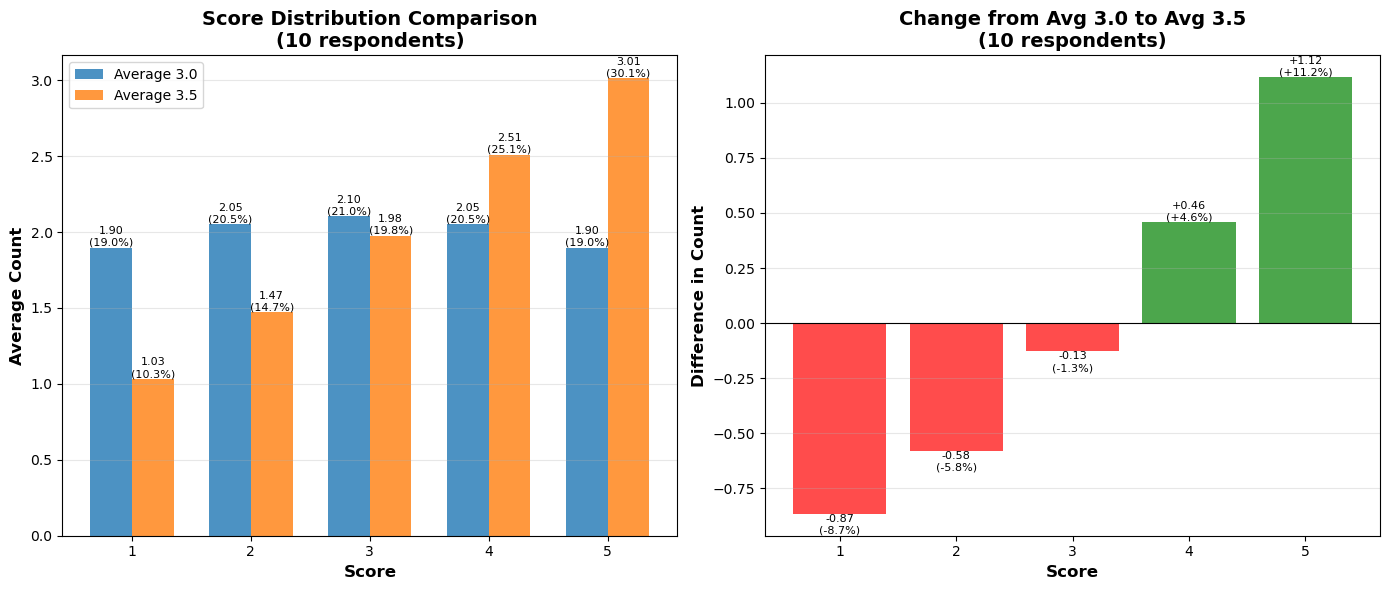



Example 2: Invalid average (not integer sum)
----------------------------------------------------------------------
Comparing average 3.0 vs 3.33 with 10 respondents

Average 3.33:
Average 3.33 is not possible with 10 respondents (sum must be integer)
  → Nearest lower average: 3.3
  → Nearest higher average: 3.4


Example 3: Average too low
----------------------------------------------------------------------
Comparing average 0.5 vs 2.0 with 10 respondents

Average 0.5:
Average 0.5 is not possible (sum 5 out of range [10, 50])
  → No lower average available
  → Nearest higher average: 1.0


Example 4: Average too high
----------------------------------------------------------------------
Comparing average 3.0 vs 5.5 with 10 respondents

Average 5.5:
Average 5.5 is not possible (sum 55 out of range [10, 50])
  → Nearest lower average: 5.0
  → No higher average available


Example 5: Show all possible averages for n=10
----------------------------------------------------------------

In [11]:
# Example usage
print("Example 1: Valid comparison")
print("-" * 70)
compare_two_averages(n_respondents=10, avg1=3.0, avg2=3.5)

print("\n\n" + "=" * 70)
print("Example 2: Invalid average (not integer sum)")
print("-" * 70)
compare_two_averages(n_respondents=10, avg1=3.0, avg2=3.33)

print("\n\n" + "=" * 70)
print("Example 3: Average too low")
print("-" * 70)
compare_two_averages(n_respondents=10, avg1=0.5, avg2=2.0)

print("\n\n" + "=" * 70)
print("Example 4: Average too high")
print("-" * 70)
compare_two_averages(n_respondents=10, avg1=3.0, avg2=5.5)

print("\n\n" + "=" * 70)
print("Example 5: Show all possible averages for n=10")
print("-" * 70)
possible = find_all_possible_averages(10)
print(f"All possible averages for 10 respondents:")
print(f"Count: {len(possible)}")
print(f"Averages: {possible[:20]}...")  # Show first 20

In [21]:
def analyze_average_range(n_respondents, start_avg=3.0, end_avg=5.0, step_size=0.1):
    """
    Analyze differences in distribution counts across a range of average scores.
    
    Parameters:
    -----------
    n_respondents : int
        Number of respondents in the population
    start_avg : float
        Starting average score (default: 3.0)
    end_avg : float
        Ending average score (default: 5.0)
    step_size : float
        Step size for the range (default: 0.1)
    
    Returns:
    --------
    dict : Dictionary containing population size, step size, and pairwise comparisons
           Each comparison contains list of tuples (delta, percent) for each score
    """
    
    # Generate the range of averages
    # Use round to avoid floating point precision issues
    num_steps = int(round((end_avg - start_avg) / step_size)) + 1
    averages = [round(start_avg + i * step_size, 10) for i in range(num_steps)]
    
    # Initialize result dictionary
    result = {
        "population_size": n_respondents,
        "step_size": step_size,
        "start_average": start_avg,
        "end_average": end_avg,
        "comparisons": {}
    }
    
    # Calculate differences for each consecutive pair
    for i in range(len(averages) - 1):
        avg1 = averages[i]
        avg2 = averages[i + 1]
        
        # Create key for this pair
        pair_key = f"({avg1:.1f}, {avg2:.1f})"
        
        # Get distribution for first average
        dist1_result = calculate_average_distribution(n_respondents, avg1)
        
        # Get distribution for second average
        dist2_result = calculate_average_distribution(n_respondents, avg2)
        
        # Check if either average is not possible
        if dist1_result[1] is not None or dist2_result[1] is not None:
            result["comparisons"][pair_key] = "N/A"
        else:
            # Calculate differences: avg2 - avg1
            avg_dist1 = dist1_result[0]
            avg_dist2 = dist2_result[0]
            
            # Store both delta and percentage for each score
            differences_with_percent = []
            for j in range(5):
                delta = avg_dist2[j] - avg_dist1[j]
                percent = (delta / n_respondents) * 100
                differences_with_percent.append((delta, percent))
            
            result["comparisons"][pair_key] = differences_with_percent
    
    return result


def print_range_analysis(result):
    """
    Pretty print the results from analyze_average_range
    
    Parameters:
    -----------
    result : dict
        Output from analyze_average_range function
    """
    print(f"Population Size: {result['population_size']}")
    print(f"Average Range: {result['start_average']} to {result['end_average']}")
    print(f"Step Size: {result['step_size']}")
    print("=" * 140)
    print(f"\n{'Pair':<20} {'Δ Score 1 (% pop)':<25} {'Δ Score 2 (% pop)':<25} {'Δ Score 3 (% pop)':<25} {'Δ Score 4 (% pop)':<25} {'Δ Score 5 (% pop)':<25}")
    print("-" * 140)
    
    for pair, differences in result["comparisons"].items():
        if differences == "N/A":
            print(f"{pair:<20} {'N/A':<25}")
        else:
            # Format each delta with its percentage
            formatted_values = []
            for delta, percent in differences:
                formatted_values.append(f"{delta:+7.4f} ({percent:+6.2f}%)")
            
            diff_str = "".join([f"{val:<25}" for val in formatted_values])
            print(f"{pair:<20}{diff_str}")
    
    print("=" * 140)

In [23]:
# Example usage
print("Example 1: Population size 20, default range (3.0 to 5.0), step 0.1")
result1 = analyze_average_range(20, step_size=0.1)
print_range_analysis(result1)

print("\n\n")

print("Example 2: Population size 5, range 3.0 to 4.0, step 0.2")
result2 = analyze_average_range(5, start_avg=3.0, end_avg=4.0, step_size=0.2)
print_range_analysis(result2)

print("\n\n")

print("Example 3: Population size 10, range 3.5 to 4.5, step 0.25")
result3 = analyze_average_range(10, start_avg=3.5, end_avg=4.5, step_size=0.25)
print_range_analysis(result3)

Example 1: Population size 20, default range (3.0 to 5.0), step 0.1
Population Size: 20
Average Range: 3.0 to 5.0
Step Size: 0.1

Pair                 Δ Score 1 (% pop)         Δ Score 2 (% pop)         Δ Score 3 (% pop)         Δ Score 4 (% pop)         Δ Score 5 (% pop)        
--------------------------------------------------------------------------------------------------------------------------------------------
(3.0, 3.1)          -0.3871 ( -1.94%)        -0.2107 ( -1.05%)        -0.0101 ( -0.05%)        +0.2009 ( +1.00%)        +0.4070 ( +2.04%)        
(3.1, 3.2)          -0.3677 ( -1.84%)        -0.2194 ( -1.10%)        -0.0303 ( -0.15%)        +0.1899 ( +0.95%)        +0.4276 ( +2.14%)        
(3.2, 3.3)          -0.3487 ( -1.74%)        -0.2271 ( -1.14%)        -0.0507 ( -0.25%)        +0.1776 ( +0.89%)        +0.4490 ( +2.24%)        
(3.3, 3.4)          -0.3299 ( -1.65%)        -0.2338 ( -1.17%)        -0.0714 ( -0.36%)        +0.1637 ( +0.82%)        +0.4713 ( +2.36%)   

## Create a comprehensive test suite that checks the following: 

 - ✅ Multinomial coefficient calculation - verifies the permutation counting is correct
 - ✅ Valid average scores - ensures distributions sum correctly and achieve target
 - ✅ Impossible averages (non-integer sums) - verifies error handling
 - ✅ Out of range averages - verifies bounds checking
 - ✅ Weighted average calculation - ensures distribution counts sum to n
 - ✅ Edge cases - minimum (1.0) and maximum (5.0) averages
 - ✅ Range analysis structure - verifies correct number of comparisons
 - ✅ Delta sum verification - ensures deltas sum to zero (conservation)
 - ✅ N/A handling - tests with population size where many averages are impossible
 - ✅ Percentage calculations - verifies percentages match expected values

In [25]:
# ============================================================================
# COMPREHENSIVE TEST SUITE
# ============================================================================

def run_tests():
    """Run comprehensive tests on all functions"""
    
    print("=" * 80)
    print("RUNNING COMPREHENSIVE TEST SUITE")
    print("=" * 80)
    
    # Test 1: count_permutations_for_distribution
    print("\n--- TEST 1: count_permutations_for_distribution ---")
    test_dist = (2, 1, 0, 1, 1)  # 5 respondents
    n = 5
    result = count_permutations_for_distribution(test_dist, n)
    expected = factorial(5) // (factorial(2) * factorial(1) * factorial(0) * factorial(1) * factorial(1))
    print(f"Distribution: {test_dist}, n={n}")
    print(f"Permutations: {result}")
    print(f"Expected: {expected}")
    print(f"✓ PASS" if result == expected else f"✗ FAIL")
    
    # Test 2: find_distributions_with_average - valid average
    print("\n--- TEST 2: find_distributions_with_average (valid) ---")
    n = 5
    avg = 3.0
    distributions, error = find_distributions_with_average(n, avg)
    print(f"n={n}, average={avg}")
    print(f"Number of distributions found: {len(distributions) if distributions else 0}")
    print(f"Error: {error}")
    # Verify all distributions sum to n and achieve target
    if distributions:
        all_valid = True
        target_sum = int(avg * n)
        for dist in distributions[:3]:  # Check first 3
            dist_sum = sum(dist)
            score_sum = sum((i+1) * count for i, count in enumerate(dist))
            if dist_sum != n or score_sum != target_sum:
                all_valid = False
            print(f"  {dist} -> sum={dist_sum}, score_sum={score_sum}")
        print(f"✓ PASS" if all_valid and error is None else f"✗ FAIL")
    
    # Test 3: find_distributions_with_average - impossible average
    print("\n--- TEST 3: find_distributions_with_average (impossible) ---")
    n = 5
    avg = 3.15  # Not possible with 5 respondents (sum would be 15.75)
    distributions, error = find_distributions_with_average(n, avg)
    print(f"n={n}, average={avg}")
    print(f"Error message: {error}")
    print(f"✓ PASS" if error is not None and distributions is None else f"✗ FAIL")
    
    # Test 4: find_distributions_with_average - out of range
    print("\n--- TEST 4: find_distributions_with_average (out of range) ---")
    n = 5
    avg = 6.0  # Impossible (max is 5.0)
    distributions, error = find_distributions_with_average(n, avg)
    print(f"n={n}, average={avg}")
    print(f"Error message: {error}")
    print(f"✓ PASS" if error is not None and distributions is None else f"✗ FAIL")
    
    # Test 5: calculate_average_distribution
    print("\n--- TEST 5: calculate_average_distribution ---")
    n = 10
    avg = 3.0
    avg_dist, error = calculate_average_distribution(n, avg)
    print(f"n={n}, average={avg}")
    if avg_dist:
        print(f"Average distribution: {[f'{x:.4f}' for x in avg_dist]}")
        total = sum(avg_dist)
        print(f"Sum of average counts: {total:.4f} (should equal {n})")
        print(f"✓ PASS" if abs(total - n) < 0.0001 else f"✗ FAIL")
    else:
        print(f"Error: {error}")
        print(f"✗ FAIL")
    
    # Test 6: Edge case - all respondents give same score
    print("\n--- TEST 6: Edge case - all same score (avg=1.0) ---")
    n = 5
    avg = 1.0
    distributions, error = find_distributions_with_average(n, avg)
    print(f"n={n}, average={avg}")
    print(f"Distributions found: {distributions}")
    print(f"Expected: [(5, 0, 0, 0, 0)]")
    print(f"✓ PASS" if distributions == [(5, 0, 0, 0, 0)] else f"✗ FAIL")
    
    # Test 7: Edge case - all respondents give max score
    print("\n--- TEST 7: Edge case - all same score (avg=5.0) ---")
    n = 5
    avg = 5.0
    distributions, error = find_distributions_with_average(n, avg)
    print(f"n={n}, average={avg}")
    print(f"Distributions found: {distributions}")
    print(f"Expected: [(0, 0, 0, 0, 5)]")
    print(f"✓ PASS" if distributions == [(0, 0, 0, 0, 5)] else f"✗ FAIL")
    
    # Test 8: analyze_average_range - basic functionality
    print("\n--- TEST 8: analyze_average_range - basic functionality ---")
    n = 10
    result = analyze_average_range(n, start_avg=3.0, end_avg=3.5, step_size=0.1)
    print(f"n={n}, range=[3.0, 3.5], step=0.1")
    print(f"Number of comparisons: {len(result['comparisons'])}")
    print(f"Expected: 5 comparisons")
    
    # Check structure
    first_key = list(result['comparisons'].keys())[0]
    first_value = result['comparisons'][first_key]
    if first_value != "N/A":
        print(f"First comparison: {first_key}")
        print(f"  Data structure: list of {len(first_value)} tuples")
        print(f"  Sample: {first_value[0]} (delta, percent)")
        
        # Verify percentages add up correctly (should sum to 0)
        delta_sum = sum(delta for delta, _ in first_value)
        percent_sum = sum(percent for _, percent in first_value)
        print(f"  Sum of deltas: {delta_sum:.6f} (should be ~0)")
        print(f"  Sum of percents: {percent_sum:.6f} (should be ~0)")
        print(f"✓ PASS" if abs(delta_sum) < 0.0001 and abs(percent_sum) < 0.0001 else f"✗ FAIL")
    
    # Test 9: analyze_average_range - with impossible averages
    print("\n--- TEST 9: analyze_average_range - with impossible averages ---")
    n = 3
    result = analyze_average_range(n, start_avg=3.0, end_avg=3.5, step_size=0.1)
    print(f"n={n}, range=[3.0, 3.5], step=0.1")
    na_count = sum(1 for v in result['comparisons'].values() if v == "N/A")
    print(f"Number of N/A results: {na_count}")
    print(f"Sample comparisons:")
    for i, (key, value) in enumerate(result['comparisons'].items()):
        if i < 3:
            print(f"  {key}: {value if value == 'N/A' else 'Valid'}")
    print(f"✓ PASS (found some N/A as expected for n=3)")
    
    # Test 10: Verify percentage calculations
    print("\n--- TEST 10: Verify percentage calculations ---")
    n = 20
    result = analyze_average_range(n, start_avg=4.0, end_avg=4.2, step_size=0.1)
    first_valid_pair = None
    for key, value in result['comparisons'].items():
        if value != "N/A":
            first_valid_pair = (key, value)
            break
    
    if first_valid_pair:
        key, values = first_valid_pair
        print(f"Pair: {key}, n={n}")
        for i, (delta, percent) in enumerate(values):
            expected_percent = (delta / n) * 100
            print(f"  Score {i+1}: delta={delta:.4f}, percent={percent:.4f}%, expected={expected_percent:.4f}%")
            if abs(percent - expected_percent) > 0.001:
                print(f"  ✗ FAIL - percentage mismatch!")
                break
        else:
            print(f"✓ PASS - all percentages correct")
    
    print("\n" + "=" * 80)
    print("TEST SUITE COMPLETE")
    print("=" * 80)

In [27]:
# ============================================================================
# RUN TESTS
# ============================================================================

if __name__ == "__main__":
    run_tests()
    
    # Run some example analyses
    print("\n\n")
    print("=" * 80)
    print("EXAMPLE ANALYSES")
    print("=" * 80)
    
    print("\n\nExample 1: Population size 20, range 3.0-4.0, step 0.2")
    result1 = analyze_average_range(20, start_avg=3.0, end_avg=4.0, step_size=0.2)
    print_range_analysis(result1)
    
    print("\n\nExample 2: Population size 10, range 4.0-5.0, step 0.25")
    result2 = analyze_average_range(10, start_avg=4.0, end_avg=5.0, step_size=0.25)
    print_range_analysis(result2)

RUNNING COMPREHENSIVE TEST SUITE

--- TEST 1: count_permutations_for_distribution ---
Distribution: (2, 1, 0, 1, 1), n=5
Permutations: 60
Expected: 60
✓ PASS

--- TEST 2: find_distributions_with_average (valid) ---
n=5, average=3.0
Number of distributions found: 12
Error: None
  (0, 0, 5, 0, 0) -> sum=5, score_sum=15
  (0, 1, 3, 1, 0) -> sum=5, score_sum=15
  (0, 2, 1, 2, 0) -> sum=5, score_sum=15
✓ PASS

--- TEST 3: find_distributions_with_average (impossible) ---
n=5, average=3.15
Error message: Average 3.15 is not possible with 5 respondents (sum must be integer)
  → Nearest lower average: 3.0
  → Nearest higher average: 3.2
✓ PASS

--- TEST 4: find_distributions_with_average (out of range) ---
n=5, average=6.0
Error message: Average 6.0 is not possible (sum 30 out of range [5, 25])
  → Nearest lower average: 5.0
  → No higher average available
✓ PASS

--- TEST 5: calculate_average_distribution ---
n=10, average=3.0
Average distribution: ['1.8973', '2.0506', '2.1043', '2.0506', '1.8

## Create a table to display the results

In [29]:
def build_full_comparison_matrix(n_respondents, start_avg=3.0, end_avg=5.0, step_size=0.1):
    """
    Build a full comparison matrix for all pairs of averages in the range.
    
    Parameters:
    -----------
    n_respondents : int
        Number of respondents in the population
    start_avg : float
        Starting average score (default: 3.0)
    end_avg : float
        Ending average score (default: 5.0)
    step_size : float
        Step size for the range (default: 0.1)
    
    Returns:
    --------
    dict : Dictionary containing:
        - population_size
        - averages: list of all average values
        - matrix: 2D dictionary where matrix[avg1][avg2] = comparison data
    """
    
    # Generate the range of averages
    num_steps = int(round((end_avg - start_avg) / step_size)) + 1
    averages = [round(start_avg + i * step_size, 10) for i in range(num_steps)]
    
    # Initialize result dictionary
    result = {
        "population_size": n_respondents,
        "step_size": step_size,
        "start_average": start_avg,
        "end_average": end_avg,
        "averages": averages,
        "matrix": {}
    }
    
    # Build comparison matrix for all pairs
    for avg1 in averages:
        result["matrix"][avg1] = {}
        for avg2 in averages:
            if avg1 == avg2:
                # Diagonal - no difference
                result["matrix"][avg1][avg2] = {
                    "differences": [(0.0, 0.0)] * 5,
                    "type": "diagonal"
                }
            else:
                # Get distributions
                dist1_result = calculate_average_distribution(n_respondents, avg1)
                dist2_result = calculate_average_distribution(n_respondents, avg2)
                
                # Check if either average is not possible
                if dist1_result[1] is not None or dist2_result[1] is not None:
                    result["matrix"][avg1][avg2] = {
                        "differences": "N/A",
                        "type": "impossible"
                    }
                else:
                    # Calculate differences: avg2 - avg1
                    avg_dist1 = dist1_result[0]
                    avg_dist2 = dist2_result[0]
                    
                    differences_with_percent = []
                    for j in range(5):
                        delta = avg_dist2[j] - avg_dist1[j]
                        percent = (delta / n_respondents) * 100
                        differences_with_percent.append((delta, percent))
                    
                    result["matrix"][avg1][avg2] = {
                        "differences": differences_with_percent,
                        "type": "valid"
                    }
    
    return result

## Visualization

In [31]:
# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

from prettytable import PrettyTable, HRuleStyle, VRuleStyle
import numpy as np

# For image generation
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Optional: for colored terminal output
try:
    from colorama import Fore, Back, Style, init
    init(autoreset=True)
    COLORAMA_AVAILABLE = True
except ImportError:
    COLORAMA_AVAILABLE = False

def calculate_color_score(differences_data):
    """
    Calculate a color score based on changes in scores 4 and 5.
    
    Parameters:
    -----------
    differences_data : list of tuples or "N/A"
        The differences data for a cell
    
    Returns:
    --------
    float or None : Score value (positive = improvement, negative = decline)
    """
    if differences_data == "N/A":
        return None
    
    # Weight score 4 and 5 changes
    delta_4 = differences_data[3][0]  # Score 4 delta
    delta_5 = differences_data[4][0]  # Score 5 delta
    
    # Give more weight to 5s than 4s
    score = delta_4 * 1.0 + delta_5 * 1.5
    
    return score


def get_cell_color_hex(score, max_score):
    """
    Get HTML hex color based on score.
    
    Parameters:
    -----------
    score : float or None
        Color score (None for N/A cells)
    max_score : float
        Maximum absolute score for normalization
    
    Returns:
    --------
    str : HTML color code
    """
    if score is None:
        return "#CCCCCC"  # Gray for N/A
    
    if max_score == 0:
        return "#F0FFF0"  # Very light green for no change
    
    # Normalize score to [-1, 1]
    normalized = score / max_score if max_score > 0 else 0
    
    if abs(normalized) < 0.05:  # Negligible difference
        return "#F0FFF0"  # Very light green
    elif normalized > 0:  # Positive (improvement - more 4s and 5s)
        if normalized < 0.3:
            return "#D4EDDA"  # Very light green
        elif normalized < 0.5:
            return "#B2DFBB"  # Light green
        elif normalized < 0.7:
            return "#70C876"  # Medium green
        elif normalized < 0.9:
            return "#28A745"  # Green
        else:
            return "#1E7E34"  # Dark green
    else:  # Negative (decline - fewer 4s and 5s)
        abs_norm = abs(normalized)
        if abs_norm < 0.3:
            return "#F8D7DA"  # Very light red
        elif abs_norm < 0.5:
            return "#F1B0B7"  # Light red
        elif abs_norm < 0.7:
            return "#E4717A"  # Medium red
        elif abs_norm < 0.9:
            return "#DC3545"  # Red
        else:
            return "#BD2130"  # Dark red


def create_comparison_table_html(matrix_data, 
                                 output_file=os.path.join("..", "html", "comparison_table.html")
                                ):
    """
    Create an HTML table visualization of the comparison matrix.
    
    Parameters:
    -----------
    matrix_data : dict
        Output from build_full_comparison_matrix
    output_file : str
        Output filename for HTML file
    
    Returns:
    --------
    str : Path to created file
    """
    averages = matrix_data["averages"]
    matrix = matrix_data["matrix"]
    n = matrix_data["population_size"]
    
    # Calculate max score for normalization
    max_score = 0
    for avg1 in averages:
        for avg2 in averages:
            cell_data = matrix[avg1][avg2]
            if cell_data["type"] == "valid":
                score = calculate_color_score(cell_data["differences"])
                if score is not None:
                    max_score = max(max_score, abs(score))
    
    # Build HTML
    html = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <title>Score Distribution Comparison Matrix</title>
        <style>
            body {{
                font-family: Arial, sans-serif;
                margin: 20px;
                background-color: #f5f5f5;
            }}
            h1 {{
                color: #333;
            }}
            .info {{
                margin-bottom: 20px;
                padding: 10px;
                background-color: white;
                border-radius: 5px;
            }}
            table {{
                border-collapse: collapse;
                background-color: white;
                box-shadow: 0 2px 4px rgba(0,0,0,0.1);
            }}
            th, td {{
                border: 1px solid #ddd;
                padding: 8px;
                text-align: center;
                min-width: 80px;
            }}
            th {{
                background-color: #4CAF50;
                color: white;
                font-weight: bold;
            }}
            .row-header {{
                background-color: #4CAF50;
                color: white;
                font-weight: bold;
            }}
            .diagonal {{
                background-color: #E8E8E8;
                color: #999;
            }}
            .legend {{
                margin-top: 20px;
                padding: 15px;
                background-color: white;
                border-radius: 5px;
            }}
            .legend-item {{
                display: inline-block;
                margin-right: 20px;
                margin-bottom: 10px;
            }}
            .legend-color {{
                display: inline-block;
                width: 30px;
                height: 20px;
                margin-right: 5px;
                vertical-align: middle;
                border: 1px solid #ccc;
            }}
            .cell-content {{
                font-size: 0.85em;
            }}
        </style>
    </head>
    <body>
        <h1>Score Distribution Comparison Matrix</h1>
        <div class="info">
            <strong>Population Size:</strong> {n}<br>
            <strong>Average Range:</strong> {matrix_data['start_average']} to {matrix_data['end_average']}<br>
            <strong>Step Size:</strong> {matrix_data['step_size']}<br>
            <strong>Color Coding:</strong> Based on changes in counts of 4s and 5s<br>
            <strong>How to Read:</strong> Each cell shows the change from row average (left) to column average (top)
        </div>
        
        <table>
            <tr>
                <th>From ↓ / To →</th>
    """
    
    # Column headers
    for avg in averages:
        html += f"<th>{avg:.1f}</th>"
    html += "</tr>\n"
    
    # Data rows
    for avg1 in averages:
        html += f"<tr><td class='row-header'>{avg1:.1f}</td>"
        
        for avg2 in averages:
            cell_data = matrix[avg1][avg2]
            
            if cell_data["type"] == "diagonal":
                html += "<td class='diagonal'>—</td>"
            elif cell_data["type"] == "impossible":
                html += "<td style='background-color: #CCCCCC;'>N/A</td>"
            else:
                differences = cell_data["differences"]
                score = calculate_color_score(differences)
                color = get_cell_color_hex(score, max_score)
                
                # Format cell content - show Δ for scores 4 and 5 with percentages
                delta_4, pct_4 = differences[3]
                delta_5, pct_5 = differences[4]
                
                cell_html = f"""<td style='background-color: {color};' title='Score 4: {delta_4:+.2f} ({pct_4:+.1f}%), Score 5: {delta_5:+.2f} ({pct_5:+.1f}%)'>
                    <div class='cell-content'>
                        4: {delta_4:+.2f} ({pct_4:+.1f}%)<br>
                        5: {delta_5:+.2f} ({pct_5:+.1f}%)
                    </div>
                </td>"""
                html += cell_html
        
        html += "</tr>\n"
    
    html += """
        </table>
        
        <div class="legend">
            <h3>Legend</h3>
            <div class="legend-item">
                <span class="legend-color" style="background-color: #CCCCCC;"></span>
                <span>N/A (impossible average)</span>
            </div>
            <div class="legend-item">
                <span class="legend-color" style="background-color: #E8E8E8;"></span>
                <span>No change (diagonal)</span>
            </div>
            <div class="legend-item">
                <span class="legend-color" style="background-color: #F0FFF0;"></span>
                <span>Negligible change</span>
            </div>
            <br>
            <div class="legend-item">
                <span class="legend-color" style="background-color: #D4EDDA;"></span>
                <span>Small improvement (more 4s/5s)</span>
            </div>
            <div class="legend-item">
                <span class="legend-color" style="background-color: #70C876;"></span>
                <span>Medium improvement</span>
            </div>
            <div class="legend-item">
                <span class="legend-color" style="background-color: #1E7E34;"></span>
                <span>Large improvement</span>
            </div>
            <br>
            <div class="legend-item">
                <span class="legend-color" style="background-color: #F8D7DA;"></span>
                <span>Small decline (fewer 4s/5s)</span>
            </div>
            <div class="legend-item">
                <span class="legend-color" style="background-color: #E4717A;"></span>
                <span>Medium decline</span>
            </div>
            <div class="legend-item">
                <span class="legend-color" style="background-color: #BD2130;"></span>
                <span>Large decline</span>
            </div>
            <p style="margin-top: 15px; font-size: 0.9em; color: #666;">
                <strong>Note:</strong> Each cell shows the change in average counts of scores 4 and 5 when moving from the row average to the column average.
                Hover over cells to see detailed percentages.
            </p>
        </div>
    </body>
    </html>
    """
    
    # Write to file
    with open(output_file, 'w') as f:
        f.write(html)
    
    print(f"✓ HTML table saved to {output_file}")
    return output_file


def create_comparison_table_image(matrix_data, 
                                  output_file=os.path.join("..", "images", "comparison_table.png"), 
                                  dpi=150, 
                                  fig_width=None, 
                                  fig_height=None, 
                                  cell_size=None):
    """
    Create an image visualization of the comparison matrix using matplotlib.
    
    Parameters:
    -----------
    matrix_data : dict
        Output from build_full_comparison_matrix
    output_file : str
        Output filename for image file (PNG or JPG)
    dpi : int
        Resolution of output image (default: 150)
    fig_width : float or None
        Figure width in inches. If None, automatically calculated (default: None)
    fig_height : float or None
        Figure height in inches. If None, automatically calculated (default: None)
    cell_size : float or None
        Size per cell in inches. Overrides fig_width/height if provided (default: None)
        Recommended values: 0.5-0.8 for many cells, 0.8-1.2 for fewer cells
    
    Returns:
    --------
    str : Path to created file
    """
    averages = matrix_data["averages"]
    matrix = matrix_data["matrix"]
    n = matrix_data["population_size"]
    
    num_avgs = len(averages)
    
    # Calculate max score for normalization
    max_score = 0
    for avg1 in averages:
        for avg2 in averages:
            cell_data = matrix[avg1][avg2]
            if cell_data["type"] == "valid":
                score = calculate_color_score(cell_data["differences"])
                if score is not None:
                    max_score = max(max_score, abs(score))
    
    # Calculate figure size
    if cell_size is not None:
        # Use cell_size to determine dimensions
        fig_width = max(8, num_avgs * cell_size + 2)  # +2 for margins and legend
        fig_height = max(6, num_avgs * cell_size + 2)
    elif fig_width is None or fig_height is None:
        # Automatic scaling based on number of cells
        # Larger tables get proportionally bigger cells for readability
        if num_avgs <= 10:
            base_cell_size = 0.9
        elif num_avgs <= 15:
            base_cell_size = 0.8
        elif num_avgs <= 20:
            base_cell_size = 0.7
        else:
            base_cell_size = 0.6
        
        if fig_width is None:
            fig_width = max(12, num_avgs * base_cell_size + 3)
        if fig_height is None:
            fig_height = max(8, num_avgs * base_cell_size + 2)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Create data matrix for visualization
    color_matrix = np.zeros((num_avgs, num_avgs, 3))
    text_matrix = [['' for _ in range(num_avgs)] for _ in range(num_avgs)]
    
    for i, avg1 in enumerate(averages):
        for j, avg2 in enumerate(averages):
            cell_data = matrix[avg1][avg2]
            
            if cell_data["type"] == "diagonal":
                color_matrix[i, j] = [0.91, 0.91, 0.91]  # Light gray
                text_matrix[i][j] = "—"
            elif cell_data["type"] == "impossible":
                color_matrix[i, j] = [0.8, 0.8, 0.8]  # Gray
                text_matrix[i][j] = "N/A"
            else:
                differences = cell_data["differences"]
                score = calculate_color_score(differences)
                
                # Get color
                hex_color = get_cell_color_hex(score, max_score)
                # Convert hex to RGB
                rgb = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (1, 3, 5))
                color_matrix[i, j] = rgb
                
                # Format text with percentages
                delta_4, pct_4 = differences[3]
                delta_5, pct_5 = differences[4]
                text_matrix[i][j] = f"4: {delta_4:+.2f} ({pct_4:+.1f}%)\n5: {delta_5:+.2f} ({pct_5:+.1f}%)"
    
    # Display the matrix
    ax.imshow(color_matrix, aspect='auto')
    
    # Add text to cells
    for i in range(num_avgs):
        for j in range(num_avgs):
            text = text_matrix[i][j]
            # Determine text color based on background
            bg_color = color_matrix[i, j]
            text_color = 'white' if sum(bg_color) < 1.5 else 'black'
            # Adjust font size based on number of averages and text length
            font_size = max(5, 9 - num_avgs * 0.15)
            ax.text(j, i, text, ha='center', va='center', 
                   fontsize=font_size, color=text_color)
    
    # Set ticks and labels
    ax.set_xticks(range(num_avgs))
    ax.set_yticks(range(num_avgs))
    ax.set_xticklabels([f"{avg:.1f}" for avg in averages], fontsize=9)
    ax.set_yticklabels([f"{avg:.1f}" for avg in averages], fontsize=9)
    
    # Labels
    ax.set_xlabel('To Average →', fontsize=11, fontweight='bold')
    ax.set_ylabel('From Average ↓', fontsize=11, fontweight='bold')
    
    # Title
    title_text = (f"Score Distribution Comparison Matrix\n"
                 f"Population: {n} | Range: {matrix_data['start_average']:.1f} to "
                 f"{matrix_data['end_average']:.1f} | Step: {matrix_data['step_size']}")
    ax.set_title(title_text, fontsize=12, fontweight='bold', pad=20)
    
    # Add legend
    legend_elements = [
        mpatches.Patch(facecolor='#CCCCCC', label='N/A (impossible)'),
        mpatches.Patch(facecolor='#F0FFF0', label='Negligible'),
        mpatches.Patch(facecolor='#D4EDDA', label='Small improvement'),
        mpatches.Patch(facecolor='#28A745', label='Large improvement'),
        mpatches.Patch(facecolor='#F8D7DA', label='Small decline'),
        mpatches.Patch(facecolor='#DC3545', label='Large decline')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
             fontsize=9, frameon=True)
    
    plt.tight_layout()
    
    # Save figure
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Image saved to {output_file}")
    return output_file


def create_comparison_table_prettytable(matrix_data, output_file=None, use_colors=False):
    """
    Create a text-based comparison table using PrettyTable.
    
    Parameters:
    -----------
    matrix_data : dict
        Output from build_full_comparison_matrix
    output_file : str or None
        Output filename for text file (default: None = print to console)
    use_colors : bool
        Use ANSI color codes for terminal output (default: False)
        Only works when output_file is None (console output)
    
    Returns:
    --------
    str : Path to created file or table string
    """
    averages = matrix_data["averages"]
    matrix = matrix_data["matrix"]
    n = matrix_data["population_size"]
    
    # Calculate max score for normalization
    max_score = 0
    for avg1 in averages:
        for avg2 in averages:
            cell_data = matrix[avg1][avg2]
            if cell_data["type"] == "valid":
                score = calculate_color_score(cell_data["differences"])
                if score is not None:
                    max_score = max(max_score, abs(score))
    
    # Create PrettyTable
    table = PrettyTable()
    
    # Set column names (header row)
    column_names = ["From↓/To→"] + [f"{avg:.1f}" for avg in averages]
    table.field_names = column_names
    
    # Set alignment
    table.align = "c"  # Center align all columns
    
    # Enable all borders (horizontal and vertical lines between every cell)
    table.hrules = HRuleStyle.ALL  # Horizontal rules between all rows
    table.vrules = VRuleStyle.ALL  # Vertical rules between all columns
    
    # Add rows
    for avg1 in averages:
        row = [f"{avg1:.1f}"]  # Row header
        
        for avg2 in averages:
            cell_data = matrix[avg1][avg2]
            
            if cell_data["type"] == "diagonal":
                cell_text = "—"
            elif cell_data["type"] == "impossible":
                cell_text = "N/A"
            else:
                differences = cell_data["differences"]
                delta_4, pct_4 = differences[3]
                delta_5, pct_5 = differences[4]
                
                # Format cell content
                cell_text = f"4:{delta_4:+.2f}({pct_4:+.1f}%)\n5:{delta_5:+.2f}({pct_5:+.1f}%)"
                
                # Add color if requested and outputting to console
                if use_colors and output_file is None and COLORAMA_AVAILABLE:
                    score = calculate_color_score(differences)
                    if score is not None and max_score > 0:
                        normalized = score / max_score
                        
                        if abs(normalized) < 0.05:
                            # Negligible - no color
                            pass
                        elif normalized > 0:
                            # Positive - green
                            if normalized >= 0.7:
                                cell_text = Fore.GREEN + Style.BRIGHT + cell_text + Style.RESET_ALL
                            else:
                                cell_text = Fore.GREEN + cell_text + Style.RESET_ALL
                        else:
                            # Negative - red
                            if abs(normalized) >= 0.7:
                                cell_text = Fore.RED + Style.BRIGHT + cell_text + Style.RESET_ALL
                            else:
                                cell_text = Fore.RED + cell_text + Style.RESET_ALL
            
            row.append(cell_text)
        
        table.add_row(row)
    
    # Add title and info
    title = f"\nScore Distribution Comparison Matrix\n"
    info = f"Population: {n} | Range: {matrix_data['start_average']:.1f} to {matrix_data['end_average']:.1f} | Step: {matrix_data['step_size']}\n"
    legend = "\nLegend: N/A = impossible average | — = no change (diagonal)\n"
    legend += "Green = improvement (more 4s/5s) | Red = decline (fewer 4s/5s)\n"
    legend += "Each cell shows: Score 4 change (% of pop) and Score 5 change (% of pop)\n"
    
    # Build output
    output = title + info + "\n" + str(table) + legend
    
    if output_file:
        # Save to file
        with open(output_file, 'w', encoding='utf-8') as f:
            # Don't include color codes in file
            if use_colors and COLORAMA_AVAILABLE:
                # Strip color codes for file output
                import re
                output_clean = re.sub(r'\x1b\[[0-9;]*m', '', output)
                f.write(output_clean)
            else:
                f.write(output)
        print(f"✓ Text table saved to {output_file}")
        return output_file
    else:
        # Print to console
        print(output)
        return output


def create_comparison_table(matrix_data, output_file, format='prettytable', 
                           dpi=150, fig_width=None, fig_height=None, cell_size=None,
                           use_colors=False):
    """
    Create a comparison table visualization in the specified format.
    
    Parameters:
    -----------
    matrix_data : dict
        Output from build_full_comparison_matrix
    output_file : str or None
        Output filename (None for console output with prettytable)
    format : str
        Output format: 'prettytable', 'html', or 'image' (default: 'prettytable')
    dpi : int
        Resolution for image output (default: 150)
    fig_width : float or None
        Figure width in inches for image output (default: None = automatic)
    fig_height : float or None
        Figure height in inches for image output (default: None = automatic)
    cell_size : float or None
        Size per cell in inches for image output (default: None = automatic)
        Overrides fig_width/height if provided
    use_colors : bool
        Use ANSI colors for prettytable console output (default: False)
    
    Returns:
    --------
    str : Path to created file or table string
    """
    if format.lower() == 'prettytable':
        return create_comparison_table_prettytable(matrix_data, output_file, use_colors)
    elif format.lower() == 'html':
        return create_comparison_table_html(matrix_data, output_file)
    elif format.lower() in ['image', 'png', 'jpg', 'jpeg']:
        return create_comparison_table_image(matrix_data, output_file, dpi, 
                                             fig_width, fig_height, cell_size)
    else:
        raise ValueError(f"Invalid format '{format}'. Use 'prettytable', 'html', or 'image'")


# ============================================================================
# DEMONSTRATION
# ============================================================================

def demo_simplified_output():
    """Demonstrate prettytable, HTML, and image outputs"""
    
    print("=" * 80)
    print("COMPARISON TABLE GENERATION - PRETTYTABLE FORMAT")
    print("=" * 80)
    
    # Example 1: PrettyTable to console (default)
    print("\n1. PrettyTable Output to Console")
    print("-" * 80)
    matrix1 = build_full_comparison_matrix(10, start_avg=3.0, end_avg=4.0, step_size=0.2)
    create_comparison_table(matrix1, output_file=None, format='prettytable')
    
    # Example 2: PrettyTable to file
    print("\n2. PrettyTable Output to File")
    print("-" * 80)
    matrix2 = build_full_comparison_matrix(15, start_avg=3.5, end_avg=4.5, step_size=0.1)
    txt_file = create_comparison_table(
        matrix2,
        os.path.join("..", "text", "comparison_table.txt"),
        format='prettytable'
    )
    
    # Example 3: PrettyTable with colors (console only)
    print("\n3. PrettyTable with Colors (if colorama available)")
    print("-" * 80)
    matrix3 = build_full_comparison_matrix(8, start_avg=3.5, end_avg=4.0, step_size=0.1)
    create_comparison_table(matrix3, output_file=None, format='prettytable', use_colors=True)
    
    # Example 4: Smaller example for better readability
    print("\n4. Small Example (better for console viewing)")
    print("-" * 80)
    matrix4 = build_full_comparison_matrix(10, start_avg=3.5, end_avg=4.0, step_size=0.25)
    create_comparison_table(matrix4, output_file=None, format='prettytable')
    
    # Example 5: Save another example to file
    print("\n5. Another Example Saved to File")
    print("-" * 80)
    matrix5 = build_full_comparison_matrix(20, start_avg=3.0, end_avg=5.0, step_size=0.2)
    txt_file2 = create_comparison_table(
        matrix5,
        os.path.join("..", "text", "comparison_large.txt"),
        format='prettytable'
    )
    
    print("\n" + "=" * 80)
    print("COMPLETE!")
    print("=" * 80)
    print("\nFiles created:")
    print(f"  • Text table: {txt_file}")
    print(f"  • Large text table: {txt_file2}")
    print("\nYou can:")
    print("  • View text files in any text editor")
    print("  • Copy/paste into emails, documents, or code")
    print("  • Print to console with format='prettytable' and output_file=None")
    print("  • Use use_colors=True for colored console output (if colorama installed)")
    print("\nOther formats still available:")
    print("  • format='html' for HTML output")
    print("  • format='image' for PNG/JPG output")


# if __name__ == "__main__":
#     demo_simplified_output()

In [33]:
demo_simplified_output()

COMPARISON TABLE GENERATION - PRETTYTABLE FORMAT

1. PrettyTable Output to Console
--------------------------------------------------------------------------------

Score Distribution Comparison Matrix
Population: 10 | Range: 3.0 to 4.0 | Step: 0.2

+-----------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+
| From↓/To→ |       3.0       |       3.2       |       3.4       |       3.6       |       3.8       |       4.0       |
+-----------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+
|    3.0    |        —        |  4:+0.20(+2.0%) |  4:+0.38(+3.8%) |  4:+0.53(+5.3%) |  4:+0.63(+6.3%) |  4:+0.69(+6.9%) |
|           |                 |  5:+0.41(+4.1%) |  5:+0.87(+8.7%) | 5:+1.37(+13.7%) | 5:+1.93(+19.3%) | 5:+2.55(+25.5%) |
+-----------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+
|    3.2    |  4:-

In [35]:
matrix_data = build_full_comparison_matrix(n_respondents=15, 
                                           start_avg=3.0, 
                                           end_avg=5.0, 
                                           step_size=0.1)

In [37]:
create_comparison_table(matrix_data, 
                        output_file=os.path.join('..', 'images', 'comps_15_3_5_point1.png'), 
                        format='image', 
                        dpi=150, 
                        fig_width=None, 
                        fig_height=None, 
                        cell_size=None,
                        use_colors=False)

✓ Image saved to ../images/comps_15_3_5_point1.png


'../images/comps_15_3_5_point1.png'

In [39]:
create_comparison_table(matrix_data, 
                        output_file=os.path.join('..', 'html', 'comps_15_3_5_point1.html'), 
                        format='html', 
                        dpi=150, 
                        fig_width=None, 
                        fig_height=None, 
                        cell_size=None,
                        use_colors=False)

✓ HTML table saved to ../html/comps_15_3_5_point1.html


'../html/comps_15_3_5_point1.html'

In [41]:
create_comparison_table(matrix_data, 
                        output_file=os.path.join('..', 'text', 'comps_15_3_5_point1.txt'), 
                        format='prettytable', 
                        dpi=150, 
                        fig_width=None, 
                        fig_height=None, 
                        cell_size=None,
                        use_colors=False)

✓ Text table saved to ../text/comps_15_3_5_point1.txt


'../text/comps_15_3_5_point1.txt'

"""
SCORE DISTRIBUTION COMPARISON TABLE - USAGE GUIDE
==================================================

This tool analyzes how score distributions change across different average values.

QUICK START
-----------

from score_distribution_complete import (
    build_full_comparison_matrix,
    create_comparison_table
)

# Step 1: Build the comparison matrix
matrix = build_full_comparison_matrix(
    n_respondents=20,       # Population size
    start_avg=3.0,          # Starting average
    end_avg=5.0,            # Ending average
    step_size=0.2           # Step size between averages
)

# Step 2: Create output (HTML or Image)

# HTML output (for copy/paste into PowerPoint)
create_comparison_table(matrix, "output.html", format='html')

# PNG image (for direct insertion into PowerPoint)
create_comparison_table(matrix, "output.png", format='image', dpi=150)

# High-resolution PNG (for printing)
create_comparison_table(matrix, "output_hires.png", format='image', dpi=300)


UNDERSTANDING THE OUTPUT
------------------------

Each cell in the table shows:
- Changes in count of 4s: e.g., "4: +0.20 (+2.0%)"
- Changes in count of 5s: e.g., "5: +0.41 (+4.1%)"

Where:
- +0.20 = average increase of 0.2 respondents scoring 4
- (+2.0%) = this represents 2% of the population

Color coding:
- Green: More 4s and 5s (improvement)
- Red: Fewer 4s and 5s (decline)
- Gray: Impossible average for that population size
- Light gray diagonal: No change (same average)


EXAMPLES
--------

# Example 1: Small population with fine granularity
matrix1 = build_full_comparison_matrix(10, 3.0, 4.0, 0.1)
create_comparison_table(matrix1, "small_pop.png", format='image')

# Example 2: Large population with coarse steps
matrix2 = build_full_comparison_matrix(100, 3.0, 5.0, 0.25)
create_comparison_table(matrix2, "large_pop.html", format='html')

# Example 3: Focused range
matrix3 = build_full_comparison_matrix(25, 3.8, 4.2, 0.05)
create_comparison_table(matrix3, "focused.png", format='image', dpi=300)


PARAMETERS
----------

build_full_comparison_matrix():
  n_respondents : int
      Number of survey respondents
  start_avg : float
      Starting average score (default: 3.0)
  end_avg : float
      Ending average score (default: 5.0)
  step_size : float
      Increment between averages (default: 0.1)

create_comparison_table():
  matrix_data : dict
      Output from build_full_comparison_matrix()
  output_file : str
      Path for output file (.html, .png, or .jpg)
  format : str
      'html' or 'image' (default: 'html')
  dpi : int
      Resolution for images only (default: 150)
      Use 150 for screens, 300 for print


TIPS
----

1. Population Size:
   - Small (n=5-15): Many averages will be impossible
   - Medium (n=20-50): Good balance
   - Large (n>50): Most averages possible, but slower to compute

2. Step Size:
   - 0.05: Very fine granularity (many cells)
   - 0.1: Good default balance
   - 0.2-0.25: Coarser, easier to read
   - Smaller populations need larger steps (e.g., 0.2-0.5)

3. Range:
   - Narrow (e.g., 3.5-4.5): Focus on specific improvement zone
   - Wide (e.g., 3.0-5.0): See full spectrum of changes

4. Output Format:
   - HTML: Best for copying into documents, interactive tooltips
   - PNG: Best for inserting into presentations, reports
   - High DPI: Use when quality matters (printing, zooming)


INTERPRETING RESULTS
--------------------

Example cell: "4: -0.23 (-1.5%)" and "5: -1.78 (-11.8%)"

This means moving from the row average to the column average:
- Count of 4s decreases by 0.23 (1.5% of population)
- Count of 5s decreases by 1.78 (11.8% of population)
- This is colored red (decline in high scores)

The percentages help you understand the magnitude:
- Small changes (<5%): Light colors
- Large changes (>15%): Dark colors


TROUBLESHOOTING
---------------

Q: Many cells show "N/A"
A: Your population size is too small for the averages you're testing.
   Try increasing n_respondents or using a larger step_size.

Q: Image text is too small
A: Reduce the number of averages by using larger step_size,
   or increase DPI and view at higher zoom.

Q: Output file is too large
A: Reduce DPI (try 100-120 for screen-only viewing),
   or use HTML instead of high-res PNG.

Q: Colors don't show improvement/decline correctly
A: The colors are based on scores 4 and 5 only.
   Green = more 4s and 5s, Red = fewer 4s and 5s.


ADVANCED USAGE
-------------

# Access the underlying data
matrix = build_full_comparison_matrix(20, 3.0, 4.0, 0.2)

# Get specific comparison
avg1 = 3.0
avg2 = 3.2
comparison = matrix["matrix"][avg1][avg2]

if comparison["type"] == "valid":
    differences = comparison["differences"]
    # differences = [(delta1, pct1), (delta2, pct2), ..., (delta5, pct5)]
    for score in range(1, 6):
        delta, percent = differences[score-1]
        print(f"Score {score}: {delta:+.2f} ({percent:+.1f}%)")


For more information, see the complete code in score_distribution_complete.py
"""

"""
IMAGE SIZING GUIDE FOR COMPARISON TABLES
=========================================

The create_comparison_table_image function now supports flexible sizing options
to accommodate different table sizes and use cases.

SIZING PARAMETERS
-----------------

create_comparison_table_image(matrix_data, output_file, dpi=150, 
                              fig_width=None, fig_height=None, cell_size=None)

1. dpi (int)
   - Resolution of the output image
   - 150 (default): Good for screen viewing and presentations
   - 300: Better for printing or when zooming is expected
   - Higher DPI = larger file size

2. cell_size (float or None)
   - EASIEST PARAMETER TO USE
   - Size of each cell in inches
   - Automatically calculates fig_width and fig_height
   - Recommended values:
     * 0.5 - 0.6: For very large tables (25+ x 25+)
     * 0.7 - 0.8: For large tables (15-25 x 15-25)
     * 0.8 - 1.0: For medium tables (10-15 x 10-15)
     * 1.0 - 1.2: For small tables (< 10 x 10)
   - Default: None (uses automatic scaling)

3. fig_width, fig_height (float or None)
   - Complete control over figure dimensions in inches
   - Use when you need exact dimensions
   - If cell_size is provided, these are ignored
   - Default: None (uses automatic scaling)


AUTOMATIC SCALING (DEFAULT)
----------------------------

When all sizing parameters are None, the function automatically scales based
on the number of cells:

Table Size          Auto Cell Size    Typical Dimensions
----------          --------------    ------------------
≤ 10 x 10          0.9 inches        ~12" x 11"
11-15 x 15         0.8 inches        ~14" x 14"
16-20 x 20         0.7 inches        ~16" x 16"
> 20 x 20          0.6 inches        ~16" x 16"


USAGE EXAMPLES
--------------

# Example 1: Let automatic sizing handle it (recommended for most cases)
matrix = build_full_comparison_matrix(15, 3.5, 4.5, 0.1)
create_comparison_table(matrix, "output.png", format='image')

# Example 2: Make cells larger for better readability
matrix = build_full_comparison_matrix(10, 3.0, 4.0, 0.2)
create_comparison_table(matrix, "output.png", format='image', cell_size=1.0)

# Example 3: Make cells smaller for a large table
matrix = build_full_comparison_matrix(20, 3.0, 5.0, 0.1)
create_comparison_table(matrix, "output.png", format='image', cell_size=0.6)

# Example 4: Exact dimensions needed (e.g., for a specific slide size)
matrix = build_full_comparison_matrix(15, 3.5, 4.5, 0.1)
create_comparison_table(matrix, "output.png", format='image', 
                       fig_width=10, fig_height=8)

# Example 5: High resolution with larger cells for printing
matrix = build_full_comparison_matrix(12, 3.0, 4.5, 0.15)
create_comparison_table(matrix, "output.png", format='image',
                       dpi=300, cell_size=1.0)


RELATIONSHIP BETWEEN PARAMETERS
-------------------------------

Range and Step Size determine table size:
- Range 3.0-5.0 with step 0.1 = 21 rows x 21 columns
- Range 3.0-4.0 with step 0.2 = 6 rows x 6 columns

Table size affects optimal cell_size:
- More cells → smaller cell_size for readability
- Fewer cells → larger cell_size to fill space

DPI affects file size but not visual layout:
- 150 DPI at cell_size=1.0 looks the same as 300 DPI at cell_size=1.0
- But 300 DPI file is ~4x larger


DECISION FLOWCHART
------------------

START
  |
  ├─ Need exact dimensions? (e.g., fitting a specific space)
  |  └─ YES → Use fig_width and fig_height
  |
  ├─ Have many cells (>20x20)?
  |  └─ YES → Use cell_size=0.5 to 0.7
  |
  ├─ Have few cells (<10x10)?
  |  └─ YES → Use cell_size=1.0 to 1.2
  |
  ├─ Printing high-quality output?
  |  └─ YES → Use dpi=300 with appropriate cell_size
  |
  └─ Otherwise
     └─ Use defaults (automatic sizing, dpi=150)


COMMON SCENARIOS
----------------

Scenario 1: Quick analysis, medium table
matrix = build_full_comparison_matrix(15, 3.0, 4.5, 0.1)
create_comparison_table(matrix, "analysis.png", format='image')
# Uses automatic sizing - perfect for quick viewing

Scenario 2: Presentation slide (16:9 aspect ratio)
matrix = build_full_comparison_matrix(10, 3.0, 4.0, 0.2)
create_comparison_table(matrix, "slide.png", format='image',
                       fig_width=16, fig_height=9, dpi=150)
# Exact dimensions for PowerPoint slide

Scenario 3: Large comprehensive analysis
matrix = build_full_comparison_matrix(25, 3.0, 5.0, 0.08)
create_comparison_table(matrix, "comprehensive.png", format='image',
                       cell_size=0.6, dpi=200)
# Smaller cells, medium-high res for detailed viewing

Scenario 4: Small focused comparison, print quality
matrix = build_full_comparison_matrix(8, 3.5, 4.0, 0.1)
create_comparison_table(matrix, "report.png", format='image',
                       cell_size=1.2, dpi=300)
# Large cells, high resolution for printed report


TROUBLESHOOTING
---------------

Problem: Text is too small to read
Solution: Increase cell_size or reduce the number of cells (larger step_size)

Problem: Image is too large to load
Solution: Reduce dpi (try 100-120) or reduce cell_size

Problem: Image doesn't fit on my slide
Solution: Use fig_width and fig_height to match your slide dimensions
          (e.g., 10 inches width for standard slide)

Problem: Lots of white space around table
Solution: Decrease cell_size or use fig_width/height for tighter fit

Problem: Cells are cramped with overlapping text
Solution: Increase cell_size or reduce number of cells in table


FILE SIZE ESTIMATES
-------------------

For a 15x15 table:
- 150 DPI, cell_size=0.8: ~150-200 KB
- 300 DPI, cell_size=0.8: ~600-800 KB
- 150 DPI, cell_size=1.2: ~200-250 KB

For a 21x21 table:
- 150 DPI, cell_size=0.6: ~400-600 KB
- 300 DPI, cell_size=0.6: ~1.5-2 MB
- 150 DPI, cell_size=0.8: ~600-800 KB
"""

In [75]:
matrix = build_full_comparison_matrix(n_respondents=20, 
                                      start_avg=3.0,  
                                      end_avg=5.0, 
                                      step_size=0.2)

In [79]:
create_comparison_table(matrix, "output.png", format='html', dpi=150)

NameError: name 'create_comparison_table_html' is not defined

## ROUGH WORK